<a href="https://colab.research.google.com/github/dtcec760-commits/quiz-6-3/blob/main/ProjectMachineAl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# !unzip /content/drive/MyDrive/dataset_machineAI.zip -d /content/dataset


Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/Colab Notebooks/dataset_machineAl.zip" -d "/content/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset_machineAl/Tomato___Tomato_Yellow_Leaf_Curl_Virus/11030437-942c-4cb4-a40e-b35236778a4b___UF.GRC_YLCV_Lab 02923.JPG  
  inflating: /content/dataset_machineAl/Tomato___Tomato_Yellow_Leaf_Curl_Virus/1104914f-f715-4b02-b551-5cdf03f54bcb___YLCV_NREC 2717.JPG  
  inflating: /content/dataset_machineAl/Tomato___Tomato_Yellow_Leaf_Curl_Virus/11061195-ce9c-4171-819d-663342a186e8___YLCV_NREC 0257.JPG  
  inflating: /content/dataset_machineAl/Tomato___Tomato_Yellow_Leaf_Curl_Virus/110c50e6-039e-4f32-bda1-26262968ab8a___YLCV_GCREC 5539.JPG  
  inflating: /content/dataset_machineAl/Tomato___Tomato_Yellow_Leaf_Curl_Virus/1114e83e-5477-483c-8bed-847b2c169c9f___YLCV_NREC 2257.JPG  
  inflating: /content/dataset_machineAl/Tomato___Tomato_Yellow_Leaf_Curl_Virus/111d4096-e9eb-4f32-9a25-f3c19b92c627___YLCV_GCREC 2209.JPG  
  inflating: /content/dataset_machineAl/Tomato___Tomato_Yellow_Leaf_Curl_Virus/1126f296-0c84-4f9d-b66b-1e9

In [ ]:
import tensorflow as tf

DATA_PATH = "/content/dataset_machineAl"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
print("\nDanh sách các lớp bệnh nhóm đang có:")
print(class_names)

Found 18160 files belonging to 10 classes.
Using 14528 files for training.
Found 18160 files belonging to 10 classes.
Using 3632 files for validation.

Danh sách các lớp bệnh nhóm đang có:
['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


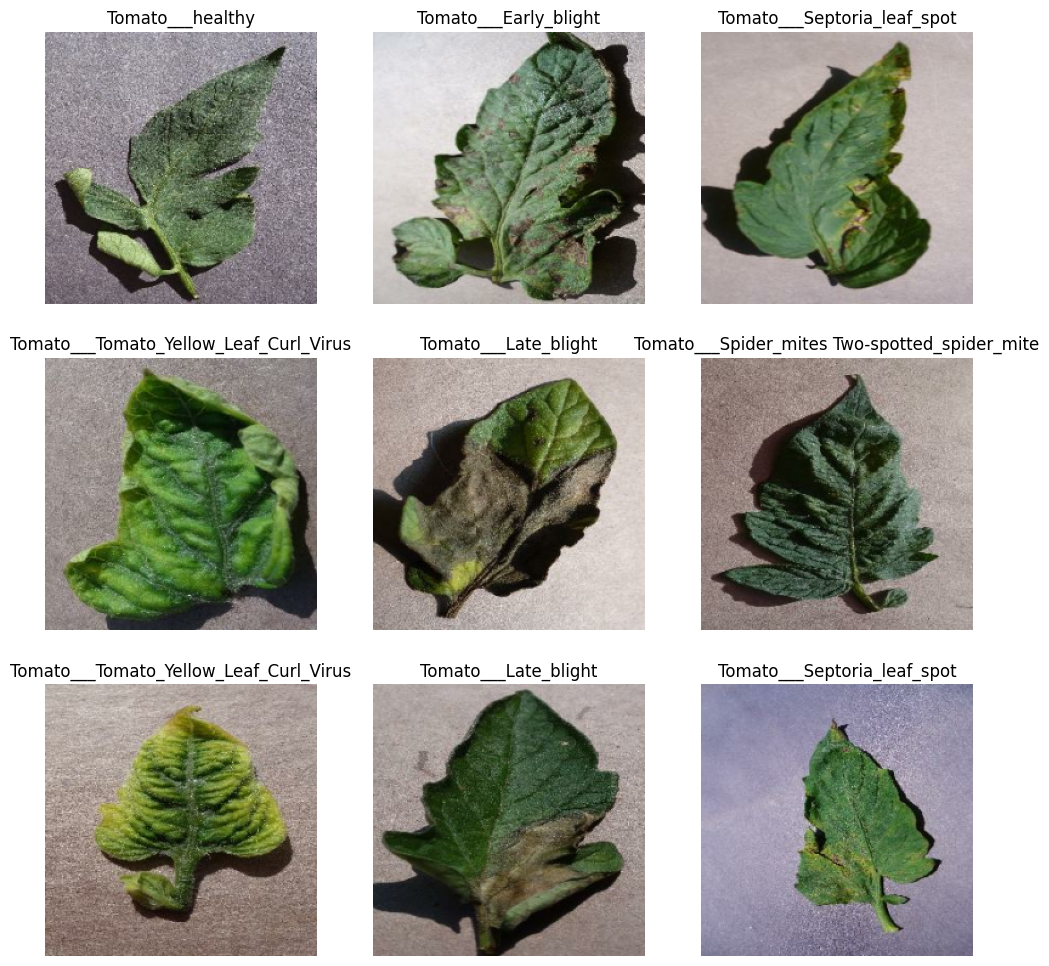

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 12))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        # Lấy tên bệnh từ label
        label_idx = np.argmax(labels[i])
        plt.title(class_names[label_idx])
        plt.axis("off")
plt.show()

In [ ]:
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
print("Đang bắt đầu huấn luyện... Nhóm đợi xíu nhé!")

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Đang bắt đầu huấn luyện... Nhóm đợi xíu nhé!
Epoch 1/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 59s 85ms/step - accuracy: 0.6415 - loss: 1.0641 - val_accuracy: 0.7552 - val_loss: 0.7249
Epoch 2/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 50s 48ms/step - accuracy: 0.7589 - loss: 0.7031 - val_accuracy: 0.8114 - val_loss: 0.5740
Epoch 3/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.7949 - loss: 0.5942 - val_accuracy: 0.8271 - val_loss: 0.5141
Epoch 4/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.8151 - loss: 0.5330 - val_accuracy: 0.8279 - val_loss: 0.5103
Epoch 5/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - accuracy: 0.8316 - loss: 0.4888 - val_accuracy: 0.8326 - val_loss: 0.4882
Epoch 6/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.8412 - loss: 0.4547 - val_accuracy: 0.8447 - val_loss: 0.4396
Epoch 7/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.8495 - loss: 0.4253 - val_accuracy: 0.8444 - val_loss: 0.4447
Epoch 8/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 21s 4

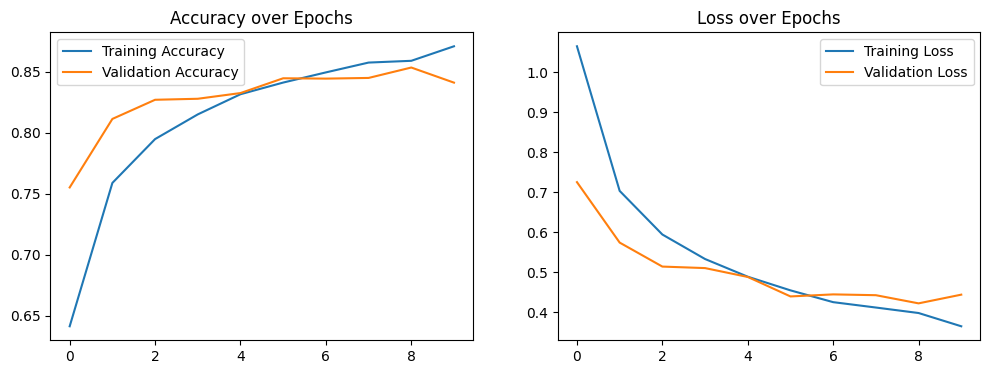

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()

In [ ]:
# Lưu vào bộ nhớ tạm của Colab
model.save('tomato_disease_model.h5')

# Hoặc lưu trực tiếp vào Drive của nhóm (nếu đã Mount Drive)
# model.save('/content/drive/MyDrive/tomato_disease_model.h5')

print("✅ Đã lưu mô hình thành công!")

✅ Đã lưu mô hình thành công!


Saving Screenshot 2026-05-12 201751.png to Screenshot 2026-05-12 201751.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


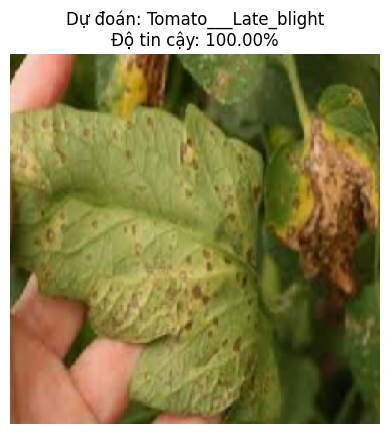

In [ ]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image

def predict_tomato_disease(model, img_path, class_names):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    prediction = model.predict(img_array)
    index = np.argmax(prediction[0])
    confidence = np.max(prediction[0])

    plt.imshow(img)
    plt.title(f"Dự đoán: {class_names[index]}\nĐộ tin cậy: {confidence*100:.2f}%")
    plt.axis('off')
    plt.show()

uploaded = files.upload()
for fn in uploaded.keys():
    predict_tomato_disease(model, fn, class_names)

Scaning

--- BÁO CÁO CHI TIẾT 10 LỚP BỆNH ---
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.97      0.80      0.88       417
                        Tomato___Early_blight       0.76      0.49      0.59       197
                         Tomato___Late_blight       0.82      0.80      0.81       400
                           Tomato___Leaf_Mold       0.74      0.86      0.79       190
                  Tomato___Septoria_leaf_spot       0.67      0.77      0.72       351
Tomato___Spider_mites Two-spotted_spider_mite       0.83      0.83      0.83       333
                         Tomato___Target_Spot       0.66      0.81      0.73       288
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.95      0.94      0.95      1070
                 Tomato___Tomato_mosaic_virus       0.68      0.76      0.72        68
                             Tomato___healthy       0.94      0.95      0.95       

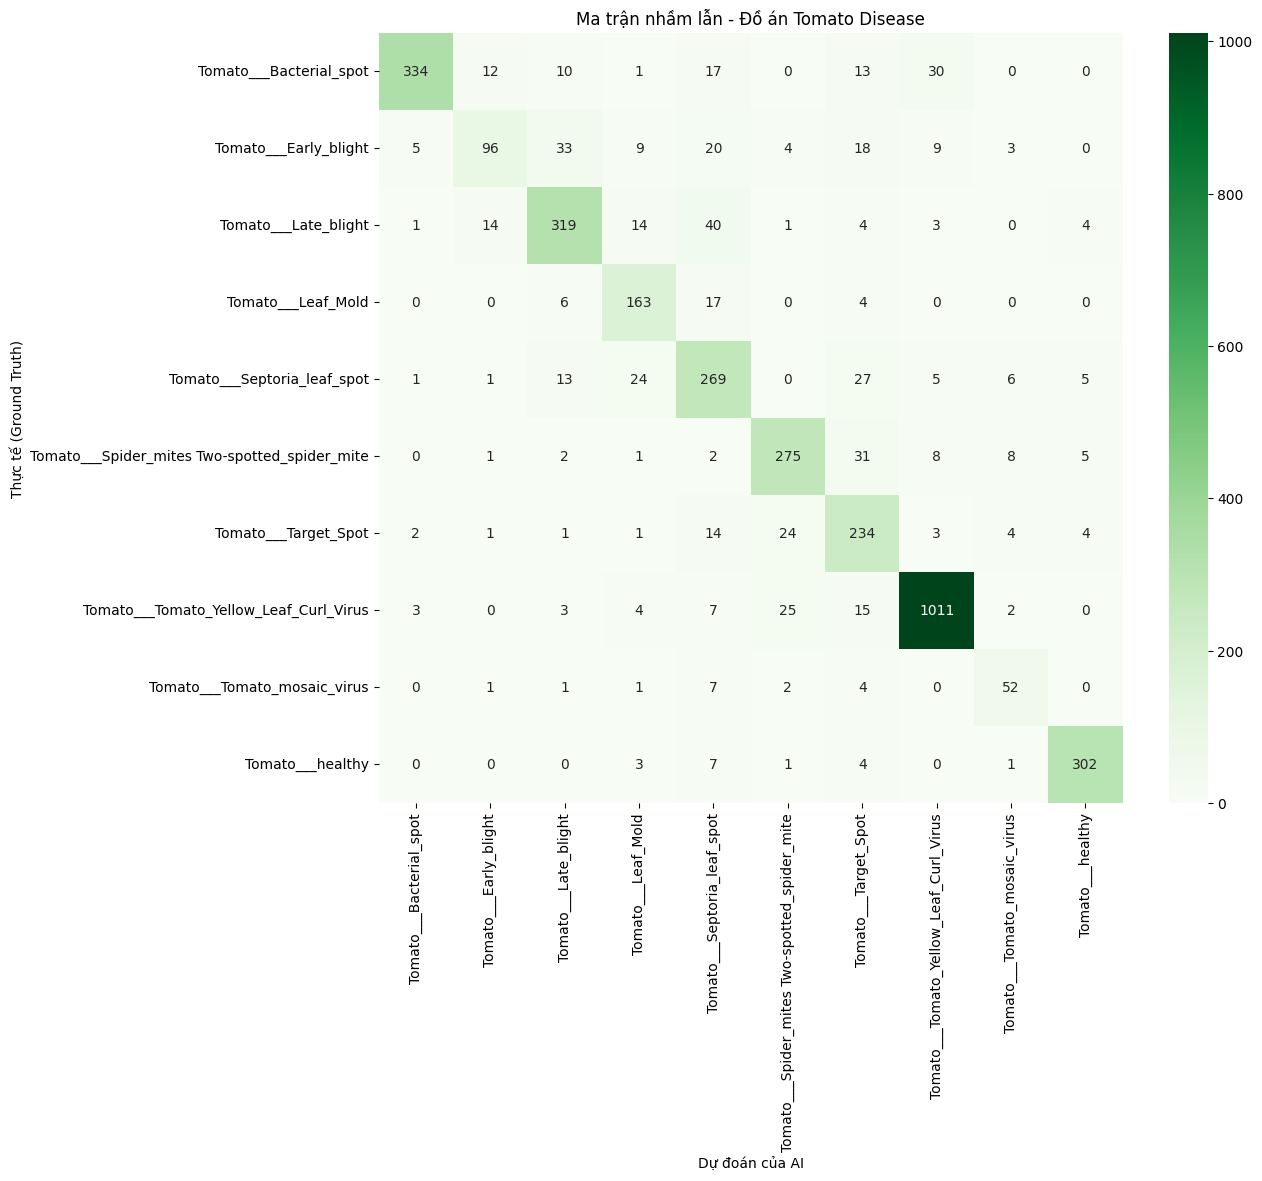

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

print("Scaning")

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)

    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# In báo cáo đầy đủ
print("\n--- BÁO CÁO CHI TIẾT 10 LỚP BỆNH ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Vẽ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
plt.xlabel('Dự đoán của AI')
plt.ylabel('Thực tế (Ground Truth)')
plt.title('Ma trận nhầm lẫn - Đồ án Tomato Disease')
plt.show()